# Init

In [1]:
import numpy as np
from machine_data import demo
from mbtrack2 import Bunch, LongitudinalMap, SynchrotronRadiation, RFCavity
from mbtrack2 import BunchSpectrumMonitor, BeamMonitor, Beam, plot_beamdata
from tqdm import tqdm
import matplotlib.pyplot as plt

np.random.seed(1)

mbtrack2 version 0.8.0.32
(dirty git work tree)
--------------------------------------------------
If used in a publication, please cite mbtrack2 paper and the zenodo archive for the corresponding code version (and other papers for more specific features).
[1] A. Gamelin, W. Foosang, N. Yamamoto, V. Gubaidulin and R. Nagaoka, “mbtrack2”. Zenodo, Dec. 16, 2024. doi: 10.5281/zenodo.14418989.
[2] A. Gamelin, W. Foosang, and R. Nagaoka, “mbtrack2, a Collective Effect Library in Python”, presented at the 12th Int. Particle Accelerator Conf. (IPAC'21), Campinas, Brazil, May 2021, paper MOPAB070.




In [2]:
ring = demo()
mp= int(10)
fill = np.ones(ring.h)
bb = Beam(ring)
nt = int(10000)

In [3]:
long = LongitudinalMap(ring)
theta0 = np.arccos(ring.U0/1.0e6)
RF = RFCavity(ring, m=1, Vc=1.0e6, theta=theta0)
sr = SynchrotronRadiation(ring)

# Damping of initial oscaillation

## No feedback

In [4]:
bb.init_beam(filling_pattern=fill, mp_per_bunch=mp, track_alive=False, mpi=False)

In [5]:
bmon = BeamMonitor(ring.h, 1, 1, nt, "save_noFB")

In [6]:
for i in tqdm(range(nt+1)):
    
    long.track(bb)
    RF.track(bb)
    sr.track(bb)
    
    bmon.track(bb)
        
bmon.close()

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10001/10001 [01:25<00:00, 116.84it/s]


## With mode 0 feedback

In [12]:
bb.init_beam(filling_pattern=fill, mp_per_bunch=mp, track_alive=False, mpi=False)

In [13]:
bmon = BeamMonitor(ring.h, 1, 1, nt, "save_FB")

In [14]:
gain = -1
delay = 10
phase_off = 0

In [15]:
for i in tqdm(range(nt+1)):
    
    long.track(bb)
    RF.track(bb)
    sr.track(bb)
    
    bmon.track(bb)
    
    if i == 10:
        tau_val = np.mean(bb.bunch_mean[4,:])
    elif i == 0:
        pass
    elif i%10 == 0:
        tau_diff = tau_val - np.mean(bb.bunch_mean[4,:])
        tau_val = np.mean(bb.bunch_mean[4,:])
        phase_diff = tau_diff*2*np.pi*ring.f1
        RF.theta = theta0 + phase_diff*gain + phase_off
        
bmon.close()

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10001/10001 [01:31<00:00, 109.25it/s]


## Plot

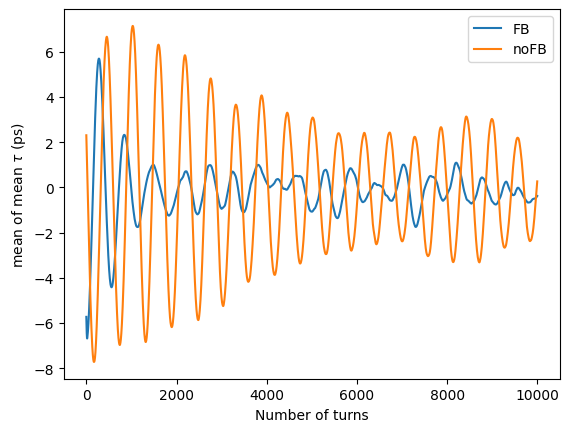

In [17]:
fig = plot_beamdata(["save_FB" + ".hdf5", "save_noFB" + ".hdf5"],
              legend=["FB","noFB"])

# With external excitation

## No feedback

In [27]:
bb.init_beam(filling_pattern=fill, mp_per_bunch=mp, track_alive=False, mpi=False)

In [28]:
bmon = BeamMonitor(ring.h, 1, 1, nt, "save_noFB_add")

In [29]:
for i in tqdm(range(nt+1)):
    
    long.track(bb)
    RF.track(bb)
    sr.track(bb)

    for bunch in bb:
        bunch["tau"] += 1e-12
    
    bmon.track(bb)
        
bmon.close()

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10001/10001 [01:56<00:00, 85.68it/s]


## With mode 0 feedback

In [32]:
bb.init_beam(filling_pattern=fill, mp_per_bunch=mp, track_alive=False, mpi=False)

In [33]:
bmon = BeamMonitor(ring.h, 1, 1, nt, "save_FB_add")

In [34]:
gain = -1
delay = 10
phase_off = 0

In [35]:
for i in tqdm(range(nt+1)):
    
    long.track(bb)
    RF.track(bb)
    sr.track(bb)

    for bunch in bb:
        bunch["tau"] += 1e-12
    
    bmon.track(bb)
    
    if i == 10:
        tau_val = np.mean(bb.bunch_mean[4,:])
    elif i == 0:
        pass
    elif i%10 == 0:
        tau_diff = tau_val - np.mean(bb.bunch_mean[4,:])
        tau_val = np.mean(bb.bunch_mean[4,:])
        phase_diff = tau_diff*2*np.pi*ring.f1
        RF.theta = theta0 + phase_diff*gain + phase_off
        
bmon.close()

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10001/10001 [01:53<00:00, 88.17it/s]


## Plot

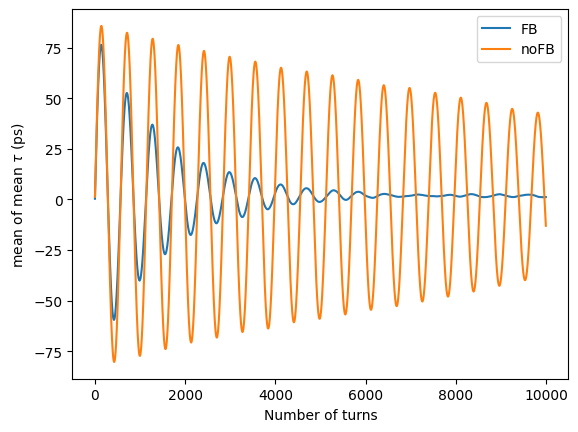

In [36]:
fig = plot_beamdata(["save_FB_add" + ".hdf5", "save_noFB_add" + ".hdf5"],
              legend=["FB","noFB"])